# 1. Objective

In this notebook, I test whether a Random Forest classifier can improve predictive performance relative to the Logistic Regression model used earlier. 
Because Random Forest can capture nonlinear relationships and feature interactions, it may identify signals that a linear model cannot. 
The goal is to evaluate whether this alternative model leads to better long-short trading performance after transaction costs.

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from src.data_loader import split_features_target
from src.data_loader import time_based_split
from src.backtest import generate_positions_from_proba
from src.backtest import strategy_returns_from_positions
from src.backtest import cumulative_returns
from src.backtest import evaluate_strategy

# 2. Load preprocessed data

In [36]:
project_root = Path.cwd().parent
data_path = project_root / "data" / "processed"
ML_dataset = pd.read_csv(data_path / "notebook_05_model_outputs" / "ML_dataset.csv", index_col=0)
clean_close_price = pd.read_csv(data_path / "notebook_02_data_prep" / "clean_close_prices.csv", index_col=0)
ML_dataset.head()

,AAPL_ret,ABBV_ret,ACN_ret,ADBE_ret,AMZN_ret,AVGO_ret,BAC_ret,BRK-B_ret,COST_ret,CRM_ret,...,NVDA_lag5,PEP_lag5,PG_lag5,SPY_lag5,TMO_lag5,UNH_lag5,V_lag5,WMT_lag5,XOM_lag5,target
Date,,,,,,,,,,,,,,,,,,,,,
2018-03-29,0.007809,0.004031,0.041313,0.016656,0.011122,-0.004352,0.020415,0.014288,0.026251,0.030298,...,-0.026996,-0.007357,-0.008178,-0.024997,-0.026437,-0.034153,-0.026213,-0.011794,-0.020522,0
2018-04-02,-0.006556,-0.033703,-0.035961,-0.017586,-0.052061,-0.033822,-0.022674,-0.022458,-0.030143,-0.008598,...,-0.036717,-0.016583,-0.006543,-0.021315,-0.012926,-0.012360,-0.024919,-0.019738,-0.008300,1
2018-04-03,0.010259,-0.009513,0.005474,0.017194,0.014621,0.039968,0.009553,0.015180,-0.000766,0.010321,...,0.049405,0.006217,0.006587,0.027359,0.024579,0.030676,0.031111,0.024350,0.015228,1
2018-04-04,0.019122,0.025941,0.007931,0.042236,0.013304,0.000887,0.009800,0.010861,0.015936,0.025667,...,-0.077552,0.007771,0.018060,-0.017011,-0.014594,-0.005067,-0.026857,-0.016571,-0.004054,1
2018-04-05,0.006935,-0.007854,0.010669,-0.006710,0.029194,-0.002870,0.014726,0.003698,0.003935,-0.003683,...,-0.018491,0.014307,0.013498,-0.002955,-0.003388,0.002477,-0.003493,0.019988,-0.012076,0


In [37]:

print(ML_dataset.shape)
print(ML_dataset.columns.tolist())
"target" in ML_dataset.columns

(2016, 311)
['AAPL_ret', 'ABBV_ret', 'ACN_ret', 'ADBE_ret', 'AMZN_ret', 'AVGO_ret', 'BAC_ret', 'BRK-B_ret', 'COST_ret', 'CRM_ret', 'CVX_ret', 'GOOGL_ret', 'HD_ret', 'JPM_ret', 'KO_ret', 'LLY_ret', 'MA_ret', 'MCD_ret', 'META_ret', 'MRK_ret', 'MSFT_ret', 'NFLX_ret', 'NVDA_ret', 'PEP_ret', 'PG_ret', 'SPY_ret', 'TMO_ret', 'UNH_ret', 'V_ret', 'WMT_ret', 'XOM_ret', 'AAPL_mom5', 'ABBV_mom5', 'ACN_mom5', 'ADBE_mom5', 'AMZN_mom5', 'AVGO_mom5', 'BAC_mom5', 'BRK-B_mom5', 'COST_mom5', 'CRM_mom5', 'CVX_mom5', 'GOOGL_mom5', 'HD_mom5', 'JPM_mom5', 'KO_mom5', 'LLY_mom5', 'MA_mom5', 'MCD_mom5', 'META_mom5', 'MRK_mom5', 'MSFT_mom5', 'NFLX_mom5', 'NVDA_mom5', 'PEP_mom5', 'PG_mom5', 'SPY_mom5', 'TMO_mom5', 'UNH_mom5', 'V_mom5', 'WMT_mom5', 'XOM_mom5', 'AAPL_mom20', 'ABBV_mom20', 'ACN_mom20', 'ADBE_mom20', 'AMZN_mom20', 'AVGO_mom20', 'BAC_mom20', 'BRK-B_mom20', 'COST_mom20', 'CRM_mom20', 'CVX_mom20', 'GOOGL_mom20', 'HD_mom20', 'JPM_mom20', 'KO_mom20', 'LLY_mom20', 'MA_mom20', 'MCD_mom20', 'META_mom20', 'MR

True

# 3. Define features and target

In [38]:
X, y = split_features_target (ML_dataset)
print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (2016, 310)
Target shape: (2016,)


# 4. Train/test split based on Time

In [39]:
X_train, X_test, y_train, y_test = time_based_split(X, y)
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("Training targets:", len(y_train))
print("Testing targets:", len(y_test))

Training samples: 1612
Testing samples: 404
Training targets: 1612
Testing targets: 404


# 5. Train Random Forest model

In [40]:
rf_model = RandomForestClassifier(n_estimators=200, max_depth=5, min_samples_leaf=10, random_state=42)
rf_model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


# 6. Predictions, probabilities, and classification check

In [41]:
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:,1]
print("First 10 probabilities:")
print(rf_prob[:10])
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))
print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

First 10 probabilities:
[0.55516732 0.58018235 0.59395915 0.57074195 0.56395035 0.53295213
 0.56822686 0.57850509 0.56034292 0.57772063]

Confusion Matrix:
[[ 13 164]
 [ 15 212]]

Classification Report:
              precision    recall  f1-score   support

           0       0.46      0.07      0.13       177
           1       0.56      0.93      0.70       227

    accuracy                           0.56       404
   macro avg       0.51      0.50      0.41       404
weighted avg       0.52      0.56      0.45       404



# 7. Convert probabilities into positions using quantile thresholds

In [42]:
rf_prob_series = pd.Series(rf_prob, index=X_test.index, name="rf_prob_series")
rf_position, long_threshold, short_threshold = generate_positions_from_proba(probabilities=rf_prob_series,
                                                                             index=X_test.index,
                                                                             upper_quantile=0.8,
                                                                             lower_quantile=0.2)
print(f"Upper threshold used: {long_threshold:.4f}")
print(f"Lower threshold used: {short_threshold:.4f}")
print("\nPosition counts:")
print(rf_position.value_counts().sort_index())


Upper threshold used: 0.5795
Lower threshold used: 0.5359

Position counts:
position
-1     81
 0    242
 1     81
Name: count, dtype: int64


# 8. Compute lagged net strategy returns

In [43]:
spy_returns = clean_close_price["SPY"].pct_change().dropna()
spy_test_returns = spy_returns.loc[rf_position.index].copy()
rf_gross_returns = strategy_returns_from_positions(positions = rf_position,
                                                   returns = spy_test_returns,
                                                   lag=1)
rf_net_returns = strategy_returns_from_positions(positions = rf_position,
                                                 returns = spy_test_returns,
                                                 lag=1,
                                                 cost_per_trade=0.0005)
pd.DataFrame({"gross": rf_gross_returns.head(10),
              "net": rf_net_returns.head(10),
              "difference": (rf_gross_returns - rf_net_returns).head(10)})


,gross,net,difference
Date,,,
2024-08-27,0.000000,0.000000,0.0000
2024-08-28,-0.005805,-0.006305,0.0005
2024-08-29,0.000089,0.000089,0.0000
2024-08-30,0.000000,-0.000500,0.0005
2024-09-03,-0.000000,-0.000000,0.0000
2024-09-04,0.002047,0.001547,0.0005
2024-09-05,-0.000000,-0.000500,0.0005
2024-09-06,-0.000000,-0.000000,0.0000
2024-09-09,0.000000,0.000000,0.0000


# 9. Compute cumulative returns

In [44]:
rf_cum_returns = cumulative_returns(rf_net_returns)
benchmark_returns = spy_test_returns.loc[rf_net_returns.index].copy()
benchmark_cum_returns = cumulative_returns(benchmark_returns)

# 10. Performance summary

In [45]:
rf_summary = evaluate_strategy(returns = rf_net_returns,
                               positions = rf_position)
benchmark_summary = evaluate_strategy(returns = spy_test_returns)
rf_results = pd.DataFrame({"Random Forest": rf_summary, "Benchmark": benchmark_summary})
rf_results

,Random Forest,Benchmark
Annualized Return,0.230930,0.118927
Annualized Volatility,0.142381,0.173347
Sharpe Ratio,1.621920,0.686062
Max Drawdown,-0.111430,-0.187552
Hit Rate,0.373391,0.561881
Exposure Rate,0.401985,NaN
Turnover,0.382134,NaN


# 11. Plot cumulative returns

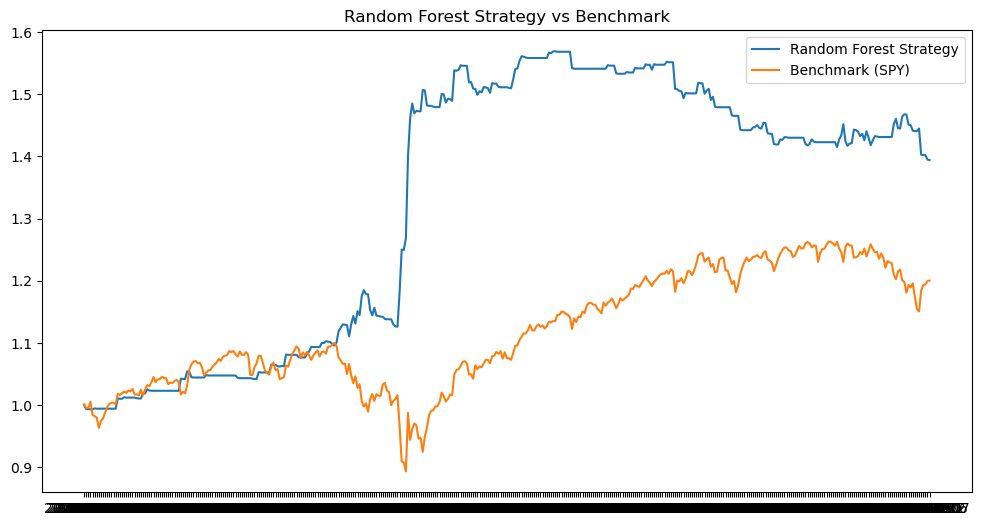

In [46]:
plt.figure(figsize=(12, 6))
plt.plot(rf_cum_returns, label="Random Forest Strategy")
plt.plot(benchmark_cum_returns, label="Benchmark (SPY)")
plt.title("Random Forest Strategy vs Benchmark")
plt.legend()
plt.show()

# 12. Feature importance analysis

In [47]:
feature_importance = pd.Series(rf_model.feature_importances_, index=X_train.columns, name="importance").sort_values(ascending=False)
feature_importance

KO_mom20      0.016851
KO_mom5       0.016226
MRK_ret       0.015290
CVX_mom5      0.008585
XOM_vol20     0.008525
                ...   
BAC_trend     0.000000
AMZN_trend    0.000000
ABBV_trend    0.000000
PEP_trend     0.000000
NVDA_trend    0.000000
Name: importance, Length: 310, dtype: float64

# 13(A). Plot feature importance: Top 20

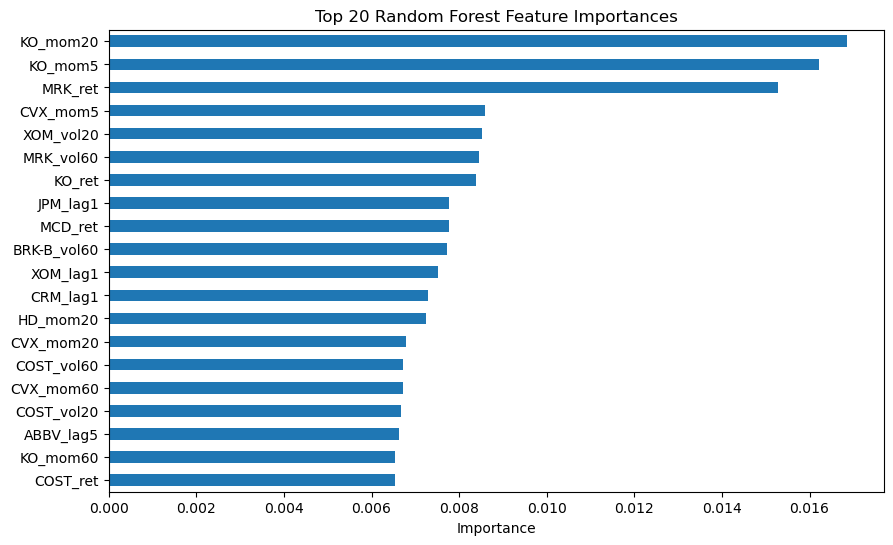

In [48]:
top_n = 20
top_features = feature_importance.head(top_n)
plt.figure(figsize=(10, 6))
top_features.sort_values().plot(kind="barh")
plt.title(f"Top {top_n} Random Forest Feature Importances")
plt.xlabel("Importance")
plt.show()

# 13(B). Plot feature importance: By Feature Family

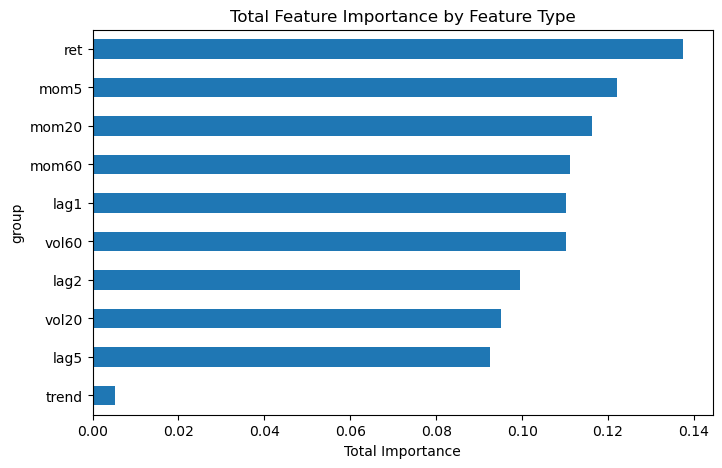

In [49]:
feature_groups = pd.DataFrame({"feature": feature_importance.index,"importance": feature_importance.values})
feature_groups["group"] = feature_groups["feature"].str.split("_").str[-1]
group_importance = feature_groups.groupby("group")["importance"].sum().sort_values(ascending=False)
plt.figure(figsize=(8, 5))
group_importance.sort_values().plot(kind="barh")
plt.title("Total Feature Importance by Feature Type")
plt.xlabel("Total Importance")
plt.show()

# 10. Conclusion

In this notebook, I introduced a Random Forest classifier as a nonlinear alternative to the Logistic Regression model used previously. The goal was to evaluate whether nonlinear relationships and feature interactions could improve predictive performance using the same dataset and time-based split.

Compared to the previous notebook, I made several key improvements. First, I replaced fixed probability thresholds with a quantile-based approach, allowing position sizing to adapt dynamically to the model’s output distribution. Second, I modularized the trading logic by fully integrating the backtest framework, ensuring consistent handling of lag, transaction costs, and performance evaluation. Third, I incorporated feature importance analysis to better understand how the model utilizes the available signals.

The results show a meaningful improvement over the benchmark across all key metrics. The Random Forest strategy achieved higher returns, lower volatility, a significantly higher Sharpe ratio, and reduced drawdown, while maintaining only partial market exposure. This suggests that the model is able to selectively identify favorable trading opportunities rather than relying on continuous exposure.

Feature importance analysis indicates that predictive power is distributed across multiple weak signals, particularly momentum and volatility-related features, while many trend-based features contribute little to the model. This highlights the presence of nonlinear interactions that were not captured by the earlier linear model.

However, the relatively flat importance distribution and the large number of features introduce the risk of overfitting. As a result, the next step is to focus on robustness and model validation. In Notebook 10, I will improve the model by pruning low-importance features, testing stability across different time periods, and comparing performance under alternative model configurations to ensure that the observed results are not driven by noise.

In [50]:
project_root = Path.cwd().parent
nb09_path = project_root / "data" / "processed" / "notebook_09_random_forest_model"
nb09_path.mkdir(parents=True, exist_ok=True)
rf_output = pd.DataFrame({"rf_pred_proba": rf_prob_series,
                          "rf_position": rf_position,
                          "rf_gross_returns": rf_gross_returns,
                          "rf_net_returns": rf_net_returns,
                          "rf_cum_returns": rf_cum_returns,
                          "benchmark_returns": benchmark_returns,
                          "benchmark_cum_returns": benchmark_cum_returns})
rf_output.to_csv(nb09_path / "random_forest_timeseries.csv")
rf_results.to_csv(nb09_path / "random_forest_results.csv")
feature_importance.to_csv(nb09_path / "random_forest_feature_importance.csv")
feature_importance.head(30).to_csv(nb09_path / "rf_top_features.csv")
thresholds = pd.DataFrame({"upper_threshold": [long_threshold], "lower_threshold": [short_threshold]})
thresholds.to_csv(nb09_path / "rf_thresholds.csv", index=False)